# Inference-Only Pipeline

**InterviewLens · MSADS Advanced Computer Vision (31023) · Final Project**

Runs **only inference** against a video, using the two **champion** models
(RTMPose-S, YOLO-World-S) -- both pretrained/off-the-shelf, no training involved.
Skips everything Notebooks 01/02 do that isn't needed to produce real evidence:
COCO/LVIS download, EDA, and training+evaluating the challenger models
(SimpleBaseline, RT-DETR-R18), which only exist for the champion-challenger
comparison tables, not for evidence extraction.

Model + extraction logic lives in `champion_inference.py` (a copy of Notebooks
01/02/03's champion-path logic, kept importable outside any single run) so this
notebook is just: load video -> load models -> run -> write evidence. Output
still lands in the same automated `outputs/<video_stem>_<timestamp>/` directory
as the full pipeline (see `shared_video.py`).

**When to use this vs. the full pipeline**: this notebook for a quick evidence
run against any video (no training, ~seconds of real compute). Notebooks
01 -> 02 -> 03 in order for the full graded deliverable (EDA, champion-challenger
training/comparison, and evidence export together).


## 1. Setup

In [1]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np

from shared_video import start_run_dir
import champion_inference as ci

DATA_DIR = Path("data")
OUTPUT_DIR = Path("outputs")
DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
Path

pathlib.Path

## 2. Video

Point this at any video under `data/` -- unlike Notebooks 01/02/03, this notebook
does **not** go through `shared_video.load_verified_video_path()`'s checksum guard
against `configs/config.yaml`: that guard exists to keep the *full* 01->02->03
pipeline's one shared demo video in sync across three separate notebook runs. This
notebook is for ad-hoc inference against whatever video you point it at, so it
takes a plain path instead. It still uses `start_run_dir()` for the same
timestamped-output-directory convention as the full pipeline.

In [ ]:
VIDEO_PATH = DATA_DIR / "test_2.mp4"
assert VIDEO_PATH.exists(), f"Video not found at {VIDEO_PATH}"

OUTPUT_DIR = start_run_dir(VIDEO_PATH, OUTPUT_DIR)
print(f"Run output directory: {OUTPUT_DIR}")

cap = cv2.VideoCapture(str(VIDEO_PATH))
VIDEO_FPS = cap.get(cv2.CAP_PROP_FPS)
VIDEO_FRAME_COUNT = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
VIDEO_WIDTH = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))An accurate and precise diagnostic matters
VIDEO_HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
VIDEO_DURATION_S = VIDEO_FRAME_COUNT / VIDEO_FPS
cap.release()

POSE_SAMPLE_FPS = 5   # matches Notebook 01
BG_SAMPLE_FPS = 3     # matches Notebook 02

print(f"Video:       {VIDEO_PATH}")
print(f"Duration:    {VIDEO_DURATION_S:.1f} s")
print(f"Source FPS:  {VIDEO_FPS:.2f}")
print(f"Resolution:  {VIDEO_WIDTH}x{VIDEO_HEIGHT}")


Run output directory: outputs/test_2_20260812_131003
Video:       data/test_2.mp4
Duration:    29.3 s
Source FPS:  25.00
Resolution:  1920x1080


## 3. Load champion models

Both pretrained -- this cell does not train anything.

In [4]:
pose_model = ci.load_pose_model()
bg_model = ci.load_background_model()
print("Champion models loaded: RTMPose-S, YOLO-World-S")


load /home/arcanegus/MSADS_/advanced_cv_31023/final_project_/InterviewLens/pipeline/notebooks/weights/rtmpose/yolox_tiny_8xb8-300e_humanart-6f3252f9.onnx with onnxruntime backend
load /home/arcanegus/MSADS_/advanced_cv_31023/final_project_/InterviewLens/pipeline/notebooks/weights/rtmpose/rtmpose-s_simcc-body7_pt-body7_420e-256x192-acd4a1ef_20230504.onnx with onnxruntime backend
Champion models loaded: RTMPose-S, YOLO-World-S


## 4. Pose inference -> `pose_evidence.json`

In [5]:
pose_evidence = ci.extract_pose_evidence(pose_model, VIDEO_PATH, POSE_SAMPLE_FPS)
print(f"Extracted pose evidence for {len(pose_evidence['frames'])} sampled frames "
      f"({pose_evidence['frames'][-1]['timestamp_s']:.1f}s span)")

events = pose_evidence["signal_events"]
print(f"{len(events)} rule-based signal events across {len({e['type'] for e in events})} rule types")
if events:
    import pandas as pd
    ev_df = pd.DataFrame(events)
    ev_df["duration_s"] = (ev_df["end_s"] - ev_df["start_s"]).round(2)
    print(ev_df.groupby("type").agg(events=("type", "size"), total_s=("duration_s", "sum")).to_string())

with open(OUTPUT_DIR / "pose_evidence.json", "w") as f:
    json.dump(pose_evidence, f, indent=2)
print(f"Wrote {OUTPUT_DIR / 'pose_evidence.json'}")


Extracted pose evidence for 147 sampled frames (29.2s span)
15 rule-based signal events across 5 rule types
           events  total_s
type                      
body_lean       1     29.2
frozen          3      1.8
head_tilt       9      8.4
nodding         1      9.8
swaying         1      5.2
Wrote outputs/test_2_20260812_131003/pose_evidence.json


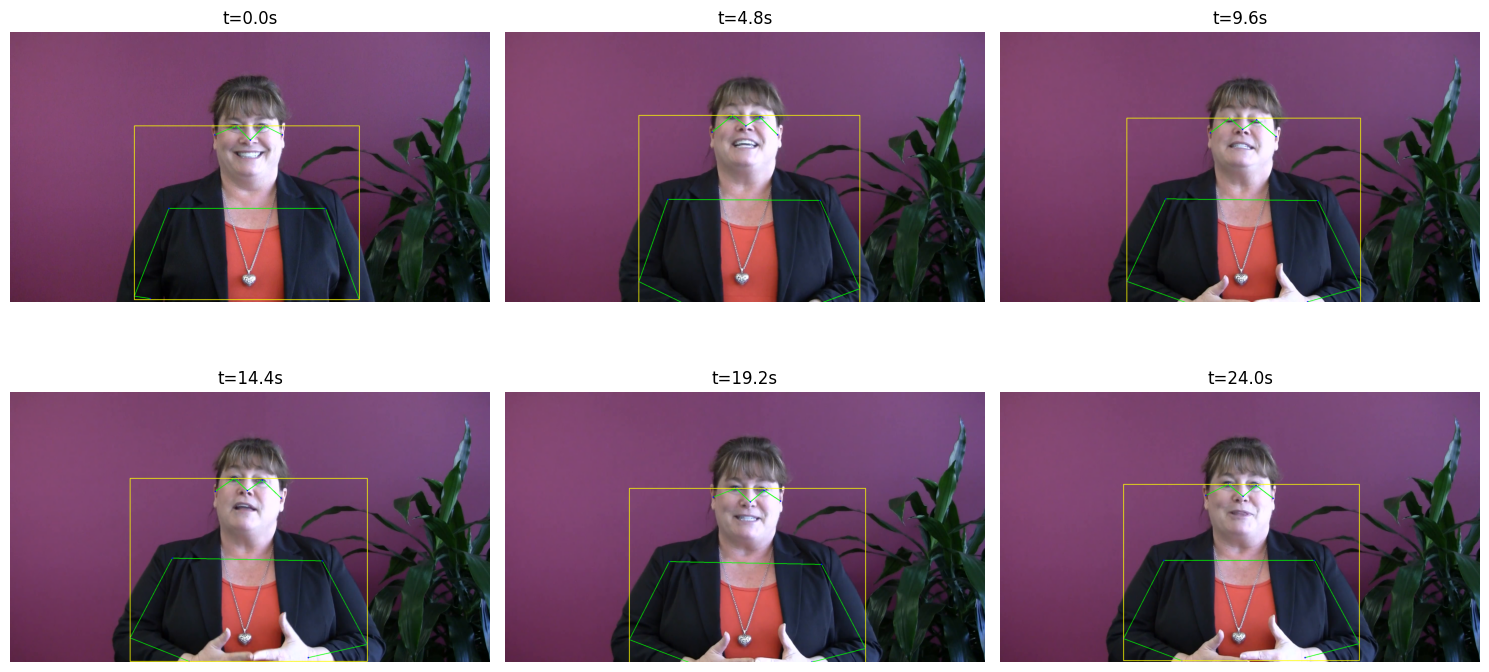

In [6]:
# Visual sanity check: sample frames spread across the video with skeleton + framing bbox
cap = cv2.VideoCapture(str(VIDEO_PATH))
check_frames = pose_evidence["frames"][:: max(1, len(pose_evidence["frames"]) // 6)][:6]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, fr in zip(axes.flat, check_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(fr["timestamp_s"] * VIDEO_FPS))
    ok, frame = cap.read()
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    kpts_arr = np.array(fr["keypoints"])
    kpts_full17 = np.zeros((17, 3))
    kpts_full17[ci.UPPER_BODY_IDX] = kpts_arr
    vis_frame = ci.draw_skeleton(frame_rgb, np.concatenate([kpts_full17[:, :2], (kpts_full17[:, 2:] > 0.3)], axis=1))
    if fr["framing"]["bbox"] is not None:
        x1, y1, x2, y2 = map(int, fr["framing"]["bbox"])
        cv2.rectangle(vis_frame, (x1, y1), (x2, y2), (255, 255, 0), 2)
    ax.imshow(vis_frame); ax.set_title(f"t={fr['timestamp_s']:.1f}s"); ax.axis("off")
cap.release()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pose_evidence_sample_frames.png", dpi=120)
plt.show()


## 5. Background inference -> `background_evidence.json`

Tracking + person-suppression (using this run's own `pose_evidence`, not a different run's).

In [7]:
tracked_frames = ci.track_objects(bg_model, VIDEO_PATH, BG_SAMPLE_FPS)
n_suppressed = ci.suppress_person_detections(tracked_frames, pose_evidence)
print(f"Suppressed {n_suppressed} detections overlapping the subject region")

track_summaries = ci.summarize_tracks(tracked_frames, VIDEO_WIDTH, VIDEO_HEIGHT)
background_evidence = {
    "video": VIDEO_PATH.name,
    "fps_sampled": BG_SAMPLE_FPS,
    "model": "YOLO-World-S",
    "taxonomy": {name: ci.CATEGORY_INFO[name][1] for name in ci.CLASS_NAMES},
    "detections": [
        {
            "track_id": t["track_id"],
            "class": t["display_name"],
            "tier": t["tier"],
            "persistence_pct": t["persistence_pct"],
            "start_s": t["start_s"],
            "end_s": t["end_s"],
            "box_area_frac": t["box_area_frac"],
        }
        for t in track_summaries
    ],
}
print(f"{len(background_evidence['detections'])} tracks after person suppression")

with open(OUTPUT_DIR / "background_evidence.json", "w") as f:
    json.dump(background_evidence, f, indent=2)
print(f"Wrote {OUTPUT_DIR / 'background_evidence.json'}")


Suppressed 0 detections overlapping the subject region
0 tracks after person suppression
Wrote outputs/test_2_20260812_131003/background_evidence.json


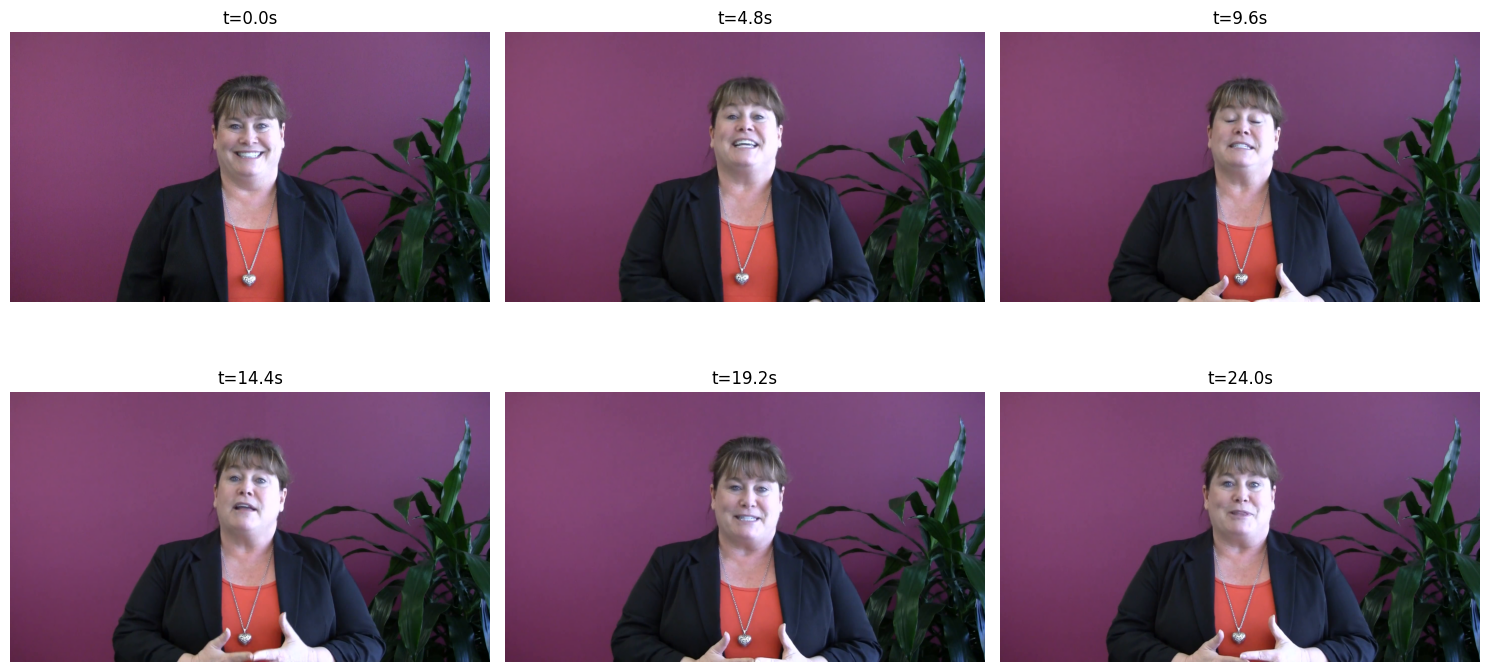

In [8]:
# Visual sanity check: sample frames spread across the video with detection+track overlays
check_frames = tracked_frames[:: max(1, len(tracked_frames) // 6)][:6]
cap = cv2.VideoCapture(str(VIDEO_PATH))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, f in zip(axes.flat, check_frames):
    cap.set(cv2.CAP_PROP_POS_FRAMES, int(f["timestamp_s"] * VIDEO_FPS))
    ok, frame = cap.read()
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    vis_frame = ci.draw_tracks(frame_rgb, f["detections"])
    ax.imshow(vis_frame); ax.set_title(f"t={f['timestamp_s']:.1f}s"); ax.axis("off")
cap.release()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "background_evidence_sample_frames.png", dpi=120)
plt.show()


## 6. Evidence fusion -> `fused_evidence.json`

In [9]:
fused_evidence = ci.fuse_evidence(pose_evidence, background_evidence)
with open(OUTPUT_DIR / "fused_evidence.json", "w") as f:
    json.dump(fused_evidence, f, indent=2)
print(f"Wrote {OUTPUT_DIR / 'fused_evidence.json'} with {len(fused_evidence['timeline'])} fused timestamps")


Wrote outputs/test_2_20260812_131003/fused_evidence.json with 88 fused timestamps


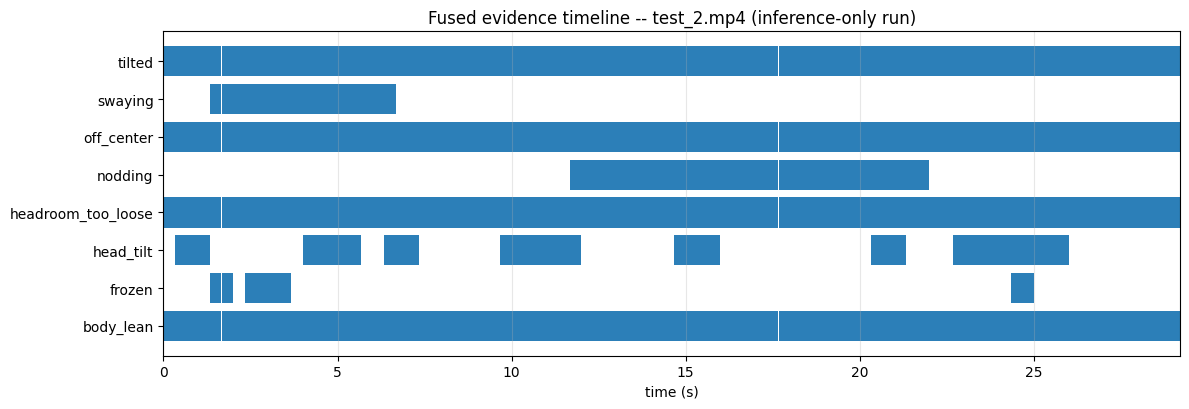

In [10]:
ALL_FLAG_TYPES = sorted({flag for pt in fused_evidence["timeline"] for flag in pt["flags"]})
step = 1.0 / fused_evidence["fps_fused"]

fig, ax = plt.subplots(figsize=(12, max(2, 0.4 * len(ALL_FLAG_TYPES) + 1)))
for row, flag_type in enumerate(ALL_FLAG_TYPES):
    spans = [(pt["timestamp_s"], step) for pt in fused_evidence["timeline"] if flag_type in pt["flags"]]
    color = "#f03b20" if flag_type.startswith("background_distracting") else (
        "#f0b429" if flag_type.startswith("background_mild") else "#2c7fb8"
    )
    ax.broken_barh(spans, (row - 0.4, 0.8), facecolors=color)

ax.set_yticks(range(len(ALL_FLAG_TYPES)))
ax.set_yticklabels(ALL_FLAG_TYPES)
ax.set_xlabel("time (s)")
ax.set_xlim(0, fused_evidence["duration_s"])
ax.set_title(f"Fused evidence timeline -- {VIDEO_PATH.name} (inference-only run)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fused_evidence_timeline.png", dpi=120)
plt.show()


## 7. Summary

In [11]:
import pandas as pd

flag_counts = pd.Series([flag for pt in fused_evidence["timeline"] for flag in pt["flags"]]).value_counts()
summary = pd.DataFrame({
    "Metric": ["Video", "Duration (s)", "Fusion FPS", "Fused timestamps", "Timestamps with >=1 flag", "Output directory"],
    "Value": [
        VIDEO_PATH.name,
        f"{fused_evidence['duration_s']:.2f}",
        fused_evidence["fps_fused"],
        len(fused_evidence["timeline"]),
        sum(1 for pt in fused_evidence["timeline"] if pt["flags"]),
        str(OUTPUT_DIR),
    ],
})
print(summary.to_string(index=False))
print()
print("Flag counts:")
print(flag_counts.to_string())

print()
print("Signal summary:")
print(json.dumps(fused_evidence["signal_summary"], indent=2))

                  Metric                          Value
                   Video                     test_2.mp4
            Duration (s)                          29.20
              Fusion FPS                              3
        Fused timestamps                             88
Timestamps with >=1 flag                             88
        Output directory outputs/test_2_20260812_131003

Flag counts:
headroom_too_loose    88
off_center            88
tilted                88
body_lean             88
head_tilt             35
nodding               31
swaying               16
frozen                 8

Signal summary:
{
  "per_type": {
    "body_lean": {
      "events": 1,
      "total_s": 29.2
    },
    "head_tilt": {
      "events": 9,
      "total_s": 8.4
    },
    "frozen": {
      "events": 3,
      "total_s": 1.8
    },
    "swaying": {
      "events": 1,
      "total_s": 5.2
    },
    "nodding": {
      "events": 1,
      "total_s": 9.8
    }
  },
  "pct_timestamps_flagged": 100